In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mart/variant_13/mart_yearly.csv")

df["year"] = pd.to_datetime(df["year"], format="%Y")
df = df.sort_values("year")

df.head()

,country_name,country_name_full,region,income_level,year,value,value_prev,value_diff,growth_rate,trend,rolling_avg_3
0,South Africa,Republic of South Africa,Africa,Upper middle income,1991-01-01,23.137,NaN,NaN,NaN,no_change,NaN
1,South Africa,Republic of South Africa,Africa,Upper middle income,1992-01-01,23.463,23.137,0.326,1.408999,growth,NaN
2,South Africa,Republic of South Africa,Africa,Upper middle income,1993-01-01,23.361,23.463,-0.102,-0.434727,decline,23.320333
3,South Africa,Republic of South Africa,Africa,Upper middle income,1994-01-01,23.067,23.361,-0.294,-1.258508,decline,23.297000
4,South Africa,Republic of South Africa,Africa,Upper middle income,1995-01-01,22.705,23.067,-0.362,-1.569341,decline,23.044333




В этом ноутбуке мы анализируем данные из витрины mart_yearly.csv.

Цель анализа:
- изучить динамику безработицы
- посмотреть распределение значений
- сравнить годы между собой

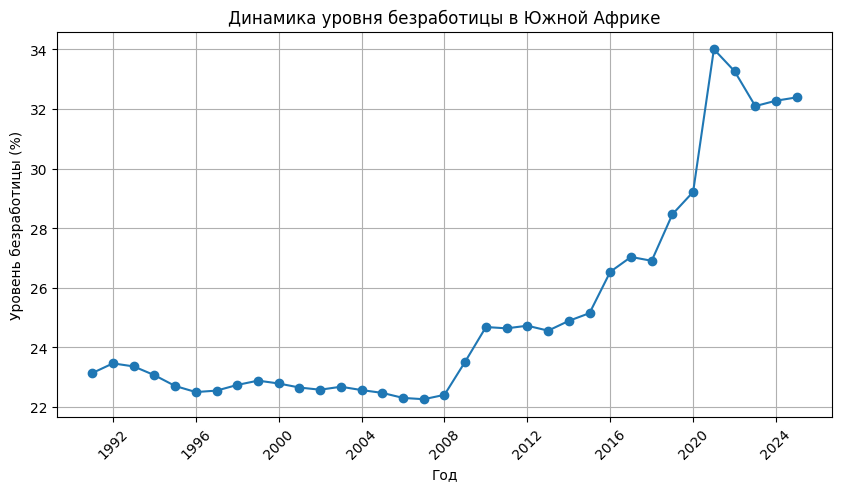

In [20]:
plt.figure(figsize=(10,5))

plt.plot(df["year"], df["value"], marker="o")

plt.title("Динамика уровня безработицы в Южной Африке")
plt.xlabel("Год")
plt.ylabel("Уровень безработицы (%)")

plt.xticks(rotation=45)
plt.grid(True)
plt.savefig("../notebooks/week7_timeseries.png")

plt.show()

## Вывод по динамике уровня безработицы

По графику видно, что уровень безработицы в Южной Африке имеет выраженную неравномерную динамику:

- в период примерно с 1991 по 2007 год показатель постепенно снижался с ~23.5% до ~22.3%
- после 2008 года начинается устойчивый рост безработицы
- особенно резкий скачок наблюдается в 2020–2021 годах, где значение достигает максимума около 34%
- после пика происходит небольшая стабилизация, но уровень остаётся высоким (~32–33%)

Таким образом, можно выделить два разных режима:
снижение в ранний период и рост с резкими кризисными скачками в последние годы.

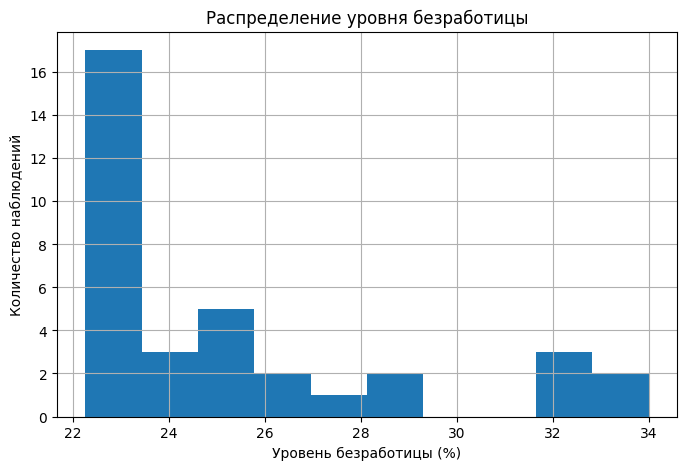

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["value"], bins=10)

plt.title("Распределение уровня безработицы")
plt.xlabel("Уровень безработицы (%)")
plt.ylabel("Количество наблюдений")

plt.grid(True)
plt.savefig("../notebooks/week7_distribution.png")
plt.show()

## Вывод по распределению уровня безработицы

Распределение значений показывает, что данные не являются равномерными:

- основная масса наблюдений сосредоточена в диапазоне примерно 22%–25%
- есть отдельный “правый хвост” значений в районе 28%–34%
- это означает, что в последние годы встречаются значительно более высокие значения безработицы
- распределение сдвинуто вправо, что указывает на рост экстремальных значений в поздний период

Можно сделать вывод, что экономика прошла период ухудшения показателя, который влияет на форму распределения.

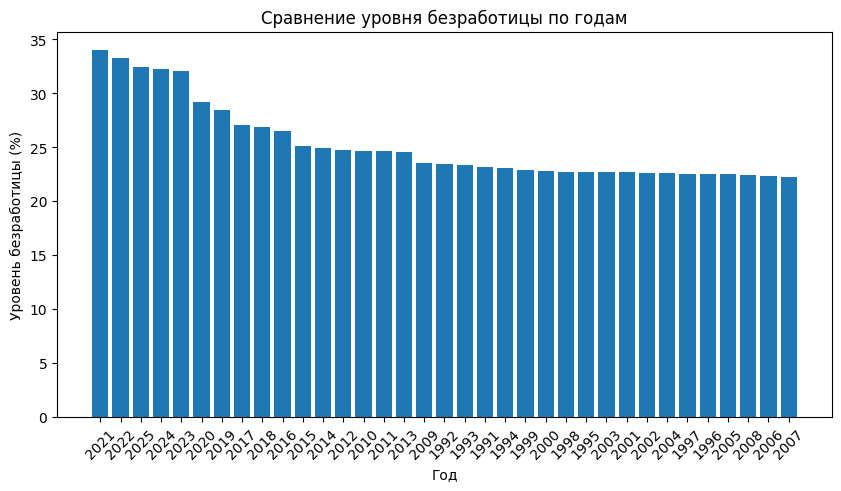

In [23]:
df_rank = df.sort_values("value", ascending=False)

plt.figure(figsize=(10,5))

plt.bar(df_rank["year"].dt.year.astype(str), df_rank["value"])

plt.title("Сравнение уровня безработицы по годам")
plt.xlabel("Год")
plt.ylabel("Уровень безработицы (%)")

plt.xticks(rotation=45)

plt.savefig("../notebooks/week7_ranking.png")

plt.show()

## Вывод по сравнению значений (bar chart)

График позволяет сравнить уровень безработицы между отдельными годами и выделить экстремальные значения:

- максимальное значение наблюдается в 2021 году и составляет около 34%
- минимальные значения находятся в районе 2006–2007 годов и составляют примерно 22.3–23%
- разница между минимумом и максимумом составляет около 11–12 процентных пунктов, что является значительным изменением

Таким образом, можно выделить два ключевых периода:
- период низкой безработицы (до 2007 года)
- период роста и кризисных значений (после 2015 года, пик в 2021)

График показывает не динамику, а масштаб различий между периодами.